[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/langchain-ai/langchain-academy/blob/main/module-1/chain.ipynb) [![Open in LangChain Academy](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66e9eba12c7b7688aa3dbb5e_LCA-badge-green.svg)](https://academy.langchain.com/courses/take/intro-to-langgraph/lessons/58238466-lesson-4-chain)

# Chain（链）

## 回顾

我们构建了一个包含节点、普通边和条件边的简单图。

## 目标

现在，让我们构建一个结合了 4 个概念的简单链。

* 使用[聊天消息](https://docs.langchain.com/oss/python/langchain/messages)作为图状态
* 在图节点中使用[聊天模型](https://docs.langchain.com/oss/python/integrations/chat)
* 为聊天模型[绑定工具](https://docs.langchain.com/oss/python/langchain/models#tool-calling)
* 在图节点中[执行工具调用](https://docs.langchain.com/oss/python/langchain/models#tool-execution-loop)

![Screenshot 2024-08-21 at 9.24.03 AM.png](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbab08dd607b08df5e1101_chain1.png)

In [1]:
%%capture --no-stderr
%pip install --quiet -U langchain_deepseek langchain_core langgraph

## Messages（消息）

聊天模型可以使用[消息](https://docs.langchain.com/oss/python/langchain/messages)，消息捕获对话中的不同角色。

LangChain 支持多种消息类型，包括 `HumanMessage`、`AIMessage`、`SystemMessage` 和 `ToolMessage`。

它们分别表示来自用户的消息、来自聊天模型的消息、用于指示聊天模型行为的消息，以及来自工具调用的消息。

让我们创建一个消息列表。

每条消息可以附带以下内容：

* `content` —— 消息内容
* `name` —— 可选，消息作者
* `response_metadata` —— 可选，元数据字典（例如，通常由模型提供商为 `AIMessages` 填充）

In [2]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage

messages = [AIMessage(content=f"So you said you were researching ocean mammals?", name="Model")]
messages.append(HumanMessage(content=f"Yes, that's right.",name="Lance"))
messages.append(AIMessage(content=f"Great, what would you like to learn about.", name="Model"))
messages.append(HumanMessage(content=f"I want to learn about the best place to see Orcas in the US.", name="Lance"))

for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Model

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, that's right.
================================== Ai Message ==================================
Name: Model

Great, what would you like to learn about.
================================ Human Message =================================
Name: Lance

I want to learn about the best place to see Orcas in the US.


## 聊天模型

聊天模型使用一系列消息作为输入，并支持上述各种消息类型。

有[很多](https://docs.langchain.com/oss/python/integrations/chat)可供选择！我们来使用 DeepSeek。

让我们检查 `DEEPSEEK_API_KEY` 是否已设置，如果没有，系统会提示你输入。

In [4]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("DEEPSEEK_API_KEY")

我们可以加载一个聊天模型并使用消息列表来调用它。

我们可以看到结果是一个带有特定 `response_metadata` 的 `AIMessage`。

In [5]:
from langchain_deepseek import ChatDeepSeek
llm = ChatDeepSeek(model="deepseek-v4-flash")
result = llm.invoke(messages)
type(result)

langchain_core.messages.ai.AIMessage

In [7]:
result

AIMessage(content='If you’re looking for the best place to see Orcas in the United States, the **San Juan Islands in Washington State** is widely considered the top destination. This is especially true for the **Southern Resident killer whales**—a unique, salmon-eating population that stays in these waters from late spring through early fall.\n\nHere’s why it’s the best, along with a few other excellent options:\n\n### 1. San Juan Islands, Washington (The #1 Choice)\n\n- **Why it’s great:** The waters around San Juan Island, particularly off the west side near **Lime Kiln Point State Park** (often called "Whale Watch Park"), are a prime feeding ground for the Southern Resident orcas. You can see them from shore or on a boat tour.\n- **Best time:** **May to September** (peak is June through August).\n- **How to do it:** Take a whale watching tour from **Friday Harbor** (on San Juan Island), or from **Anacortes** on the mainland. Kayak tours are also available for a more intimate experie

In [8]:
result.response_metadata

{'token_usage': {'completion_tokens': 857,
  'prompt_tokens': 52,
  'total_tokens': 909,
  'completion_tokens_details': {'accepted_prediction_tokens': None,
   'audio_tokens': None,
   'reasoning_tokens': 152,
   'rejected_prediction_tokens': None},
  'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0},
  'prompt_cache_hit_tokens': 0,
  'prompt_cache_miss_tokens': 52},
 'model_provider': 'deepseek',
 'model_name': 'deepseek-v4-flash',
 'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402',
 'id': '641fa5d1-c878-4da5-b0b3-00eb04221c3d',
 'finish_reason': 'stop',
 'logprobs': None}

## Tools（工具）

当你希望模型与外部系统交互时，工具非常有用。

外部系统（如 API）通常需要特定的输入 Schema 或负载，而不是自然语言。

例如，当我们将 API 绑定为工具时，我们让模型知道了所需的输入 Schema。

模型将根据用户的自然语言输入来选择是否调用工具。

并且，它会返回符合工具 Schema 的输出。

[许多 LLM 提供商支持工具调用](https://docs.langchain.com/oss/python/integrations/chat)，LangChain 中的[工具调用接口](https://blog.langchain.com/improving-core-tool-interfaces-and-docs-in-langchain/)也很简单。

你只需将任意 Python `function` 传递给 `ChatModel.bind_tools(function)` 即可。

![Screenshot 2024-08-19 at 7.46.28 PM.png](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbab08dc1c17a7a57f9960_chain2.png)

让我们展示一个简单的工具调用示例！

`multiply` 函数就是我们的工具。

In [9]:
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

llm_with_tools = llm.bind_tools([multiply])

如果我们传入一个输入 —— 例如 `"What is 2 multiplied by 3"` —— 我们会看到一个工具调用被返回。

该工具调用包含与函数输入 Schema 匹配的特定参数，以及要调用的函数名称。

```
{'arguments': '{"a":2,"b":3}', 'name': 'multiply'}
```

In [10]:
tool_call = llm_with_tools.invoke([HumanMessage(content=f"What is 2 multiplied by 3", name="Lance")])

In [11]:
tool_call.tool_calls

[{'name': 'multiply',
  'args': {'a': 2, 'b': 3},
  'id': 'call_00_It34CiZqOLOdN07csyzI8052',
  'type': 'tool_call'}]

## 使用消息作为状态

有了这些基础，我们现在可以在图状态中使用[消息](https://docs.langchain.com/oss/python/langchain/overview#messages)。

让我们定义状态 `MessagesState`，它是一个带有单个键 `messages` 的 `TypedDict`。

`messages` 就是一个消息列表，如我们上面所定义的那样（例如 `HumanMessage` 等）。

In [12]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage

class MessagesState(TypedDict):
    messages: list[AnyMessage]

## Reducers（归约器）

现在，我们有一个小问题！

如前所述，每个节点都会为状态键 `messages` 返回一个新值。

但是，这个新值会覆盖之前的 `messages` 值！

随着图的运行，我们希望将消息**追加**到 `messages` 状态键中。

我们可以使用[归约器函数](https://docs.langchain.com/oss/python/langgraph/graph-api#reducers)来解决这个问题。

归约器指定状态更新的执行方式。

如果没有指定归约器函数，则默认该键的更新会*覆盖*它，就像我们之前看到的那样。

但是，要追加消息，我们可以使用预置的 `add_messages` 归约器。

这确保所有消息都会追加到现有的消息列表中。

我们只需要用 `add_messages` 归约器函数作为元数据来标注 `messages` 键。

In [13]:
from typing import Annotated
from langgraph.graph.message import add_messages

class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

由于在图状态中使用消息列表是如此常见，LangGraph 提供了一个预置的 [`MessagesState`](https://docs.langchain.com/oss/python/langgraph/graph-api#messagesstate)！

`MessagesState` 的定义如下：

* 带有预置的单个 `messages` 键
* 这是一个 `AnyMessage` 对象的列表
* 它使用 `add_messages` 归约器

我们通常会使用 `MessagesState`，因为它比上面展示的自定义 `TypedDict` 更简洁。

In [15]:
from langgraph.graph import MessagesState

class MessagesState(MessagesState):
    # 在此添加除已预置的 messages 之外还需要的新键
    pass

让我们更深入地看看 `add_messages` 归约器是如何独立工作的。

In [16]:
# 初始状态
initial_messages = [AIMessage(content="Hello! How can I assist you?", name="Model"),
                    HumanMessage(content="I'm looking for information on marine biology.", name="Lance")
                   ]

# 要添加的新消息
new_message = AIMessage(content="Sure, I can help with that. What specifically are you interested in?", name="Model")

# 测试
add_messages(initial_messages , new_message)

[AIMessage(content='Hello! How can I assist you?', additional_kwargs={}, response_metadata={}, name='Model', id='2f6bcb15-a6bb-4d63-9fe2-10881a0916b7', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content="I'm looking for information on marine biology.", additional_kwargs={}, response_metadata={}, name='Lance', id='1c005a85-5ea3-48b7-92eb-8ed0c2c66b92'),
 AIMessage(content='Sure, I can help with that. What specifically are you interested in?', additional_kwargs={}, response_metadata={}, name='Model', id='bf12a38f-dfc3-4d94-963f-1d17209618e7', tool_calls=[], invalid_tool_calls=[])]

## 我们的图

现在，让我们在图中使用 `MessagesState`。

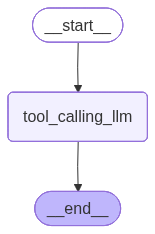

In [17]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
    
# 节点
def tool_calling_llm(state: MessagesState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# 构建图
builder = StateGraph(MessagesState)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_edge(START, "tool_calling_llm")
builder.add_edge("tool_calling_llm", END)
graph = builder.compile()

# 查看
display(Image(graph.get_graph().draw_mermaid_png()))

如果我们传入 `Hello!`，LLM 会在不调用任何工具的情况下做出响应。

In [18]:
messages = graph.invoke({"messages": HumanMessage(content="Hello!")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello!
================================== Ai Message ==================================

Hello! How can I help you today?


当 LLM 判断输入或任务需要使用工具提供的功能时，它会选择使用工具。

In [19]:
messages = graph.invoke({"messages": HumanMessage(content="Multiply 2 and 3")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (call_00_pRwl8QA8RnpfZwaQe5XY4994)
 Call ID: call_00_pRwl8QA8RnpfZwaQe5XY4994
  Args:
    a: 2
    b: 3
